In [17]:
# VADER Sentiment Analysis with Multiple Naive Bayes Models

import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB, GaussianNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import joblib
import numpy as np

# Setup
nltk.download('vader_lexicon')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:

# Dense transformer for GaussianNB
class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        if hasattr(X, 'toarray'):
            return X.toarray()
        return X

# Sentiment classification using VADER
def classify_sentiment(text):
    if not isinstance(text, str):
        text = ""
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Text preprocessing
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    return [word for word in words if word not in stop_words]

# Visualization functions
def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x=df['Sentiment'], 
        palette='coolwarm', 
        order=['Positive', 'Neutral', 'Negative']
    )
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=['Negative', 'Neutral', 'Positive'], 
        yticklabels=['Negative', 'Neutral', 'Positive']
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [19]:
# Load and prepare data
train_df = pd.read_csv('train_dataset.csv')
test_df = pd.read_csv('test_dataset.csv')

train_df = pd.read_csv('train_dataset_1000.csv')
test_df = pd.read_csv('test_dataset_1000.csv')
train_df = pd.read_csv('train_dataset_3000.csv')
test_df = pd.read_csv('test_dataset_3000.csv')
train_df = pd.read_csv('train_dataset_5000.csv')
test_df = pd.read_csv('test_dataset_5000.csv')

In [20]:
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)

# Label data with VADER
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)


In [21]:
# Save labeled data
train_df.to_csv('train_dataset_sentiment_vader.csv', index=False)
test_df.to_csv('test_dataset_sentiment_vader.csv', index=False)

train_df.to_csv('train_dataset_sentiment_vader_1000.csv', index=False)
test_df.to_csv('test_dataset_sentiment_vader_1000.csv', index=False)
train_df.to_csv('train_dataset_sentiment_vader_3000.csv', index=False)
test_df.to_csv('test_dataset_sentiment_vader_3000.csv', index=False)
train_df.to_csv('train_dataset_sentiment_vader_5000.csv', index=False)
test_df.to_csv('test_dataset_sentiment_vader_5000.csv', index=False)


📊 Sentiment Counts (Train):
Sentiment
Neutral     2969
Positive    2643
Negative    1484
Name: count, dtype: int64

📊 Sentiment Counts (Test):
Sentiment
Neutral     701
Positive    669
Negative    404
Name: count, dtype: int64

=== Training ComplementNB ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
ComplementNB Best Validation F1: 0.7229
ComplementNB Best Parameters: {'nb__alpha': 1.0, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

=== Training GaussianNB ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GaussianNB Best Validation F1: 0.6030
GaussianNB Best Parameters: {'tfidf__max_df': 0.8, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}

=== Training BernoulliNB ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
BernoulliNB Best Validation F1: 0.7643
BernoulliNB Best Parameters: {'nb__alpha': 0.1, 'tfidf__max_df': 0.8, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)}

=== Final Evaluation on Test Set ===



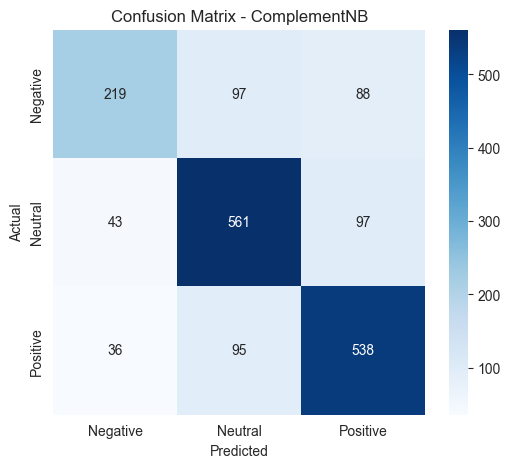


🔍 GaussianNB Test Performance:
Accuracy: 0.6234
Classification Report:
              precision    recall  f1-score   support

    Negative       0.41      0.58      0.48       404
     Neutral       0.71      0.94      0.81       701
    Positive       0.78      0.31      0.45       669

    accuracy                           0.62      1774
   macro avg       0.63      0.61      0.58      1774
weighted avg       0.67      0.62      0.60      1774



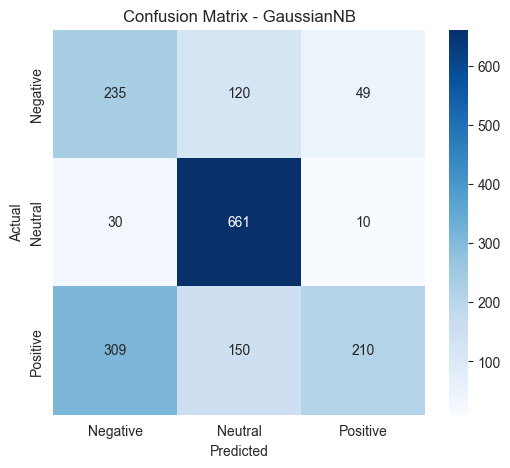


🔍 BernoulliNB Test Performance:
Accuracy: 0.7903
Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.54      0.62       404
     Neutral       0.85      0.90      0.87       701
    Positive       0.76      0.83      0.79       669

    accuracy                           0.79      1774
   macro avg       0.78      0.76      0.76      1774
weighted avg       0.79      0.79      0.78      1774



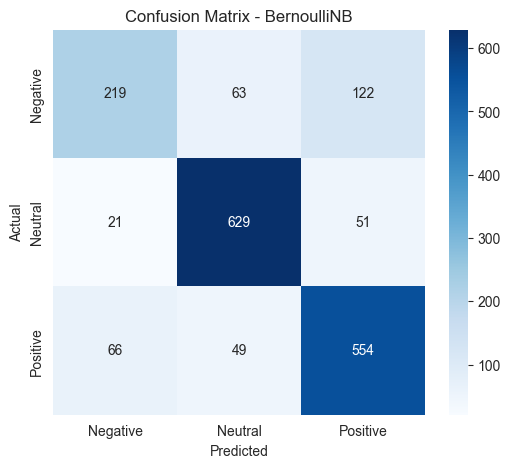

In [22]:
# Encode labels
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)
test_df['Sentiment_Label'] = test_df['Sentiment'].map(sentiment_mapping)

# Clean data
train_df.dropna(subset=['Sentiment_Label'], inplace=True)
test_df.dropna(subset=['Sentiment_Label'], inplace=True)

train_df['Sentiment_Label'] = train_df['Sentiment_Label'].astype(int)
test_df['Sentiment_Label'] = test_df['Sentiment_Label'].astype(int)

# Display numerical sentiment distribution (counts)
print("\n📊 Sentiment Counts (Train):")
print(train_df['Sentiment'].value_counts())
print("\n📊 Sentiment Counts (Test):")
print(test_df['Sentiment'].value_counts())

# Prepare train/val/test splits
X = train_df['Final_Comment']
y = train_df['Sentiment_Label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_test = test_df['Final_Comment']
y_test = test_df['Sentiment_Label']

# Define models
models = {
    'ComplementNB': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('nb', ComplementNB())
    ]),
    'GaussianNB': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('to_dense', DenseTransformer()),
        ('scaler', MinMaxScaler()),
        ('nb', GaussianNB())
    ]),
    'BernoulliNB': Pipeline([
        ('tfidf', TfidfVectorizer(binary=True)),
        ('nb', BernoulliNB())
    ])
}

# Parameter grids
param_grids = {
    'ComplementNB': {
        'tfidf__max_df': [0.8, 1.0],
        'tfidf__min_df': [1, 5],
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'nb__alpha': [0.1, 0.5, 1.0]
    },
    'GaussianNB': {
        'tfidf__max_df': [0.8, 1.0],
        'tfidf__min_df': [1, 5],
        'tfidf__ngram_range': [(1, 1), (1, 2)]
    },
    'BernoulliNB': {
        'tfidf__max_df': [0.8, 1.0],
        'tfidf__min_df': [1, 5],
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'nb__alpha': [0.1, 0.5, 1.0]
    }
}

results = {}

# Train and evaluate models
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    # Store results
    results[name] = {
        'best_params': grid.best_params_,
        'best_score': grid.best_score_,
        'model': grid.best_estimator_,
        'val_predictions': grid.predict(X_val),
        'val_accuracy': accuracy_score(y_val, grid.predict(X_val))
    }
    
    print(f"{name} Best Validation F1: {grid.best_score_:.4f}")
    print(f"{name} Best Parameters: {grid.best_params_}")

# Test set evaluation
print("\n=== Final Evaluation on Test Set ===")
for name, res in results.items():
    y_pred = res['model'].predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Neutral", "Positive"],
        output_dict=True
    )
    
    results[name].update({
        'test_predictions': y_pred,
        'test_accuracy': accuracy,
        'test_report': report
    })
    
    print(f"\n🔍 {name} Test Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Neutral", "Positive"]
    ))
    plot_confusion_matrix(y_test, y_pred, f"Confusion Matrix - {name}")
    
    # Save classification report to JSON
    with open(f"classification_report_{name.lower()}_vader.json", "w") as f:
        json.dump(report, f, indent=2)

# Save classification report to JSON
    with open(f"classification_report_{name.lower()}_vader.json", "w") as f:
        json.dump(report, f, indent=2)

C:\Users\amirb\AppData\Local\Temp\ipykernel_16128\22401009.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


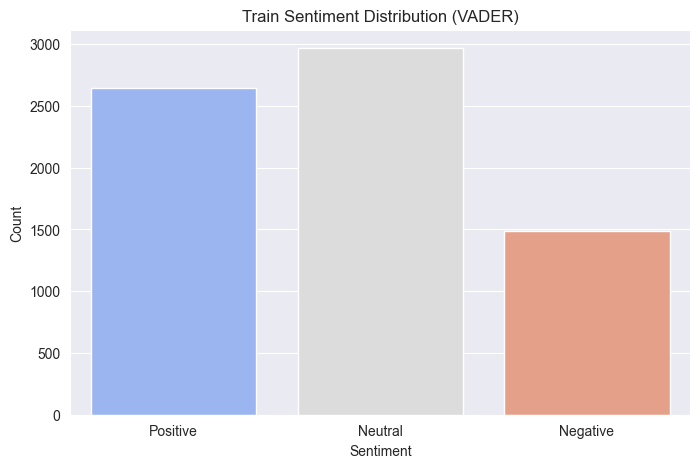

C:\Users\amirb\AppData\Local\Temp\ipykernel_16128\22401009.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


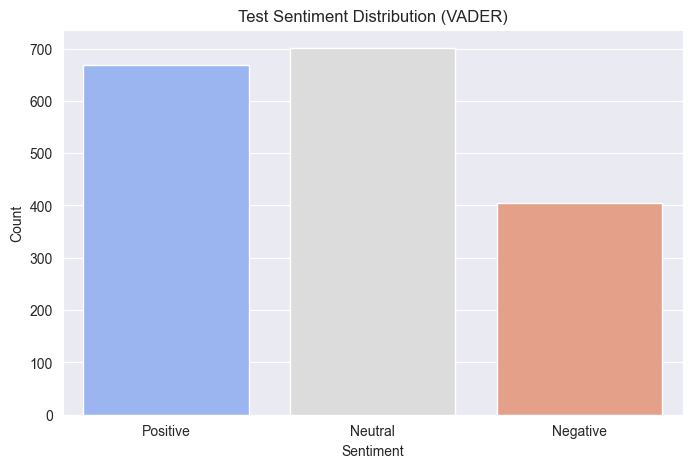


 Best Model: BernoulliNB with validation F1: 0.7643


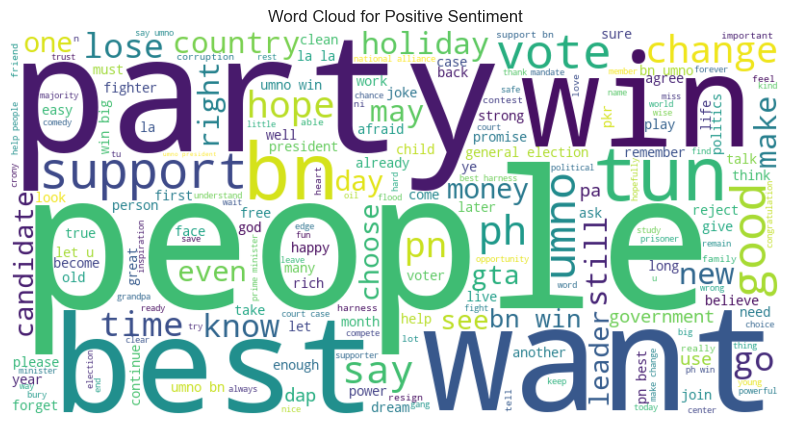

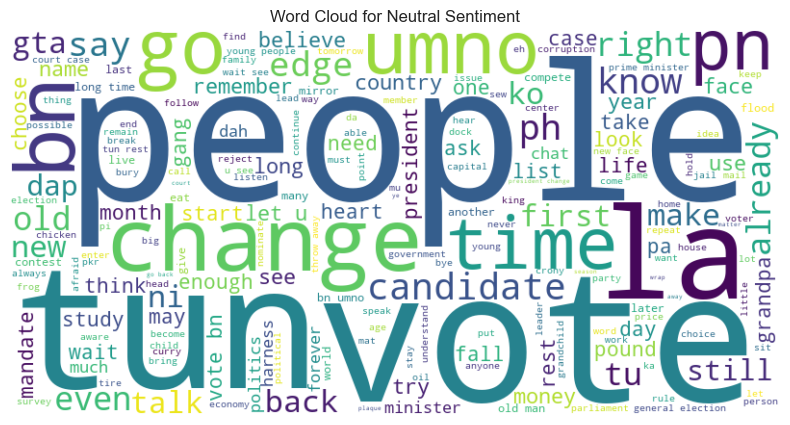

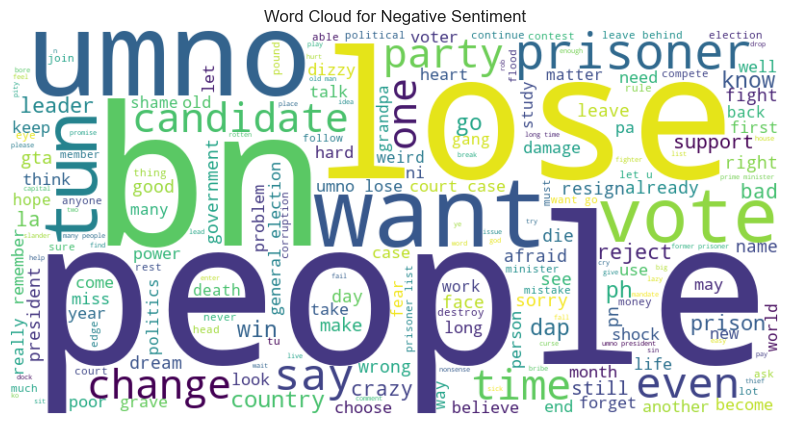

In [23]:
    
# Plot sentiment distributions
plot_sentiment_distribution(train_df, "Train Sentiment Distribution (VADER)")
plot_sentiment_distribution(test_df, "Test Sentiment Distribution (VADER)")

# Determine best model based on validation F1
best_model_name = max(results, key=lambda x: results[x]['best_score'])
best_model = results[best_model_name]['model']
print(f"\n Best Model: {best_model_name} with validation F1: {results[best_model_name]['best_score']:.4f}")

# Word clouds
for sentiment in ["Positive", "Neutral", "Negative"]:
    words = train_df[
        train_df['Sentiment'] == sentiment
    ]['Final_Comment'].apply(preprocess_text).sum()
    text = ' '.join(words)
    wordcloud = WordCloud(
        width=800, height=400, background_color='white'
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment} Sentiment")
    plt.show()

# Save all trained models
for name, res in results.items():
    model_to_save = res['model']
    filename = f"model_{name.lower()}_vader.joblib"
    joblib.dump(model_to_save, filename)
    print(f"✅ Model saved: {filename}")

In [24]:
# Save all trained models
for name, res in results.items():
    model_to_save = res['model']
    filename = f"model_{name.lower()}_vader.joblib"
    joblib.dump(model_to_save, filename)
    print(f"✅ Model saved: {filename}")

✅ Model saved: model_complementnb_vader.joblib
✅ Model saved: model_gaussiannb_vader.joblib
✅ Model saved: model_bernoullinb_vader.joblib


    
combined_df = pd.concat(
    [
        pd.read_csv('train_dataset_sentiment_vader.csv'),
        pd.read_csv('test_dataset_sentiment_vader.csv')
    ],
    ignore_index=True
)
combined_df.to_csv('combined_sentiment_nb_vader.csv', index=False)
print("✅ Combined sentiment dataset saved as 'combined_sentiment_nb_vader.csv'")


# Feature importance (for models that support it)
if hasattr(best_model.named_steps['nb'], 'feature_log_prob_'):
    feature_names = best_model.named_steps['tfidf'].get_feature_names_out()
    log_probs = best_model.named_steps['nb'].feature_log_prob_
    
    for i, label in enumerate(["Negative", "Neutral", "Positive"]):
        top_features = sorted(zip(log_probs[i], feature_names), reverse=True)[:10]
        words, scores = zip(*top_features)
        plt.figure(figsize=(8, 4))
        sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
        plt.title(f"Top Words for {label} Sentiment ({best_model_name})")
        plt.xlabel("Log Probability")
        plt.ylabel("Words")
        plt.show()